In [45]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from torch.utils.data import Dataset, DataLoader
from captum.attr import IntegratedGradients

In [46]:
# Configuration and device setup
device = torch.device('cpu')
hyper_params = {
    "input_size" : 6,
    "sequence_length" : 92,
    "batch_size" : 1000,
    "num_layers" : 2,
    "hidden_size" : 128,
    "dropout": 0.05
}

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [47]:
# Loading the historical S&P 500 data as per Freeborough and van Zyl (2022)
raw_data = pd.read_csv("data/Raw_data.csv",index_col=0)
training_df = pd.read_csv("data/Train.csv", index_col=0)
val_df = pd.read_csv("data/Val.csv", index_col=0)
test_df = pd.read_csv("data/Test.csv", index_col=0)

In [48]:
"""
Prepare test dataset:
This concatenate a portion of the validation set with the test set to ensure that the very first prediction in the test set has the required 92-day look-back window
"""
test_df = pd.concat([val_df.iloc[-(hyper_params['sequence_length'] + 7):, :], test_df])

In [49]:
"""
Custom PyTorch Dataset designed to structure raw financial data into a format suitable for time-series forecasting
"""
class Sequential_Data(Dataset):
    def __init__(self, data, window):
        self.data = torch.Tensor(data.values)
        self.window = window
    def __getitem__(self, index):
        x = self.data[index:index+self.window] # input x; days 1 through 92
        y = self.data[index+6+self.window, 3] # prediction target y; price on day 99 -> 7-day ahead forecast
        return x, y
    def __len__(self):
        return len(self.data) - self.window - 7

In [50]:
"""
Load in the data using the custom dataset
This creates structured training and testing sets where each item is a 92-day sequence of S&P 500 data paired with a target price from 7 days in the future
"""
training_data = Sequential_Data(training_df, hyper_params['sequence_length']) # look back at exactly 92 days of history for every single prediction
test_data = Sequential_Data(test_df,hyper_params['sequence_length'])

# Load training data into a data loader
trainloader = DataLoader(dataset=training_data, batch_size=hyper_params['batch_size'], shuffle=False, num_workers=0)

In [51]:
"""
Define the LSTM model and load pre-trained weights
"""
class LSTM(nn.Module):
    """
    The architecture consists of two LSTM layers followed by a ReLU activation and a final Linear layer to produce a single numerical price prediction.
    """
    def __init__(self, input_size, hidden_size, num_layers, drop_p):
        super(LSTM, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.drop_p = drop_p
        # layer
        self.lstm = nn.LSTM(input_size,hidden_size,num_layers,batch_first=True,dropout=drop_p)
        self.relu = nn.ReLU()
        self.sig = nn.Sigmoid()
        # fully connected layer
        self.fc = nn.Linear(in_features=hidden_size,out_features=1)

    def forward(self, x):
        # initialise hidden and cell state
        h0 = torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(device)

        output, _ = self.lstm(x,(h0,c0))
        # last hidden state
        last_out = self.relu(output[:, -1, :])

        prediction = self.fc(last_out)

        return prediction

# initialise architecture
model = LSTM(input_size=hyper_params['input_size'],
            hidden_size=hyper_params['hidden_size'],
            num_layers=hyper_params['num_layers'],
            drop_p=hyper_params['dropout']).to(device)

# loading weights
model.load_state_dict(torch.load("LSTM.pt", map_location=device))

# setting to train mode (this is needed for the IG method to work)
model.train()

LSTM(
  (lstm): LSTM(6, 128, num_layers=2, batch_first=True, dropout=0.05)
  (relu): ReLU()
  (sig): Sigmoid()
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [52]:
"""
Setup for Integrated Gradients
"""
# create the mean baseline
def mean_base(DF):
    """
    Creates a neutral baseline dataframe by calculating the mean of the previous 92-day window for every data point.
    """
    COPY = DF.copy()
    for i in np.arange(298,93,-1):
        COPY.iloc[i,:] = np.mean(np.array(DF.iloc[i-92:i-1,:]),axis = 0)
    return COPY

# generate the specific baseline and input tensors
mean_df = mean_base(test_df)
mean_data = Sequential_Data(mean_df, hyper_params['sequence_length'])
test_data = Sequential_Data(test_df, hyper_params['sequence_length'])

mean_loader = DataLoader(dataset=mean_data, batch_size=len(mean_data), shuffle=False)
testloader = DataLoader(dataset=test_data, batch_size=len(test_data), shuffle=False)

# aligning baseline and input
mean_baseline = next(iter(mean_loader))[0][1:].to(device)
mean_input = next(iter(testloader))[0][1:].to(device)

# initialize Integrated Gradients
ig = IntegratedGradients(model)
# calculate the integral of the gradients from the baseline to the actual input
at_mean_ig = ig.attribute(mean_input, baselines=mean_baseline, method='gausslegendre', target=0) # specifically explain the first output neuron which corresponds to the price prediction

# average the results across the batch to identify which of the 92 days were most influential
avg_ig = np.mean(at_mean_ig.detach().numpy(), axis=0)


In [53]:
# Layer-wise Relevance Propagation
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

# define the composite
composite = EpsilonGammaBox(low=-1., high=1.)

# prepare input
X = mean_input.clone().detach().requires_grad_(True)

# create the attributor
with Gradient(model=model, composite=composite) as attributor:
    output = model(X)

    # target the single output prediction
    out_relevance = torch.zeros_like(output)
    out_relevance[:, 0] = 1

    # run the attribution
    _, attribution_lrp = attributor(X, out_relevance)

avg_lrp = attribution_lrp.mean(0).detach().cpu().numpy()


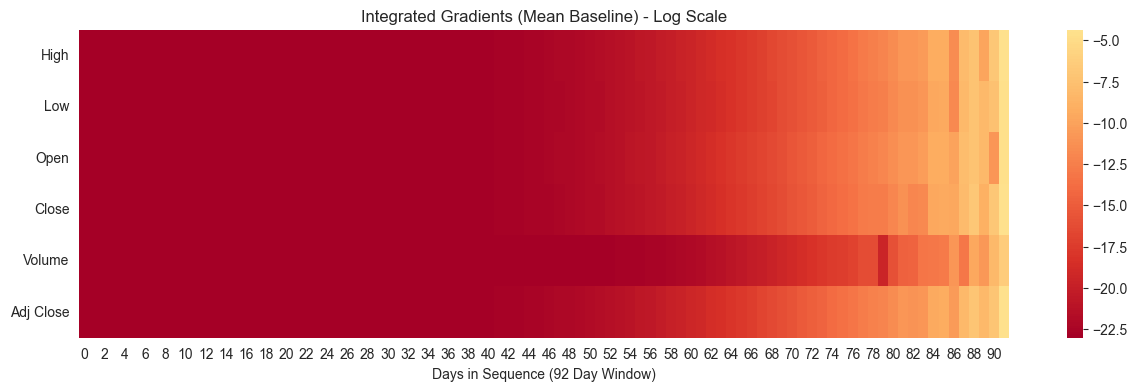

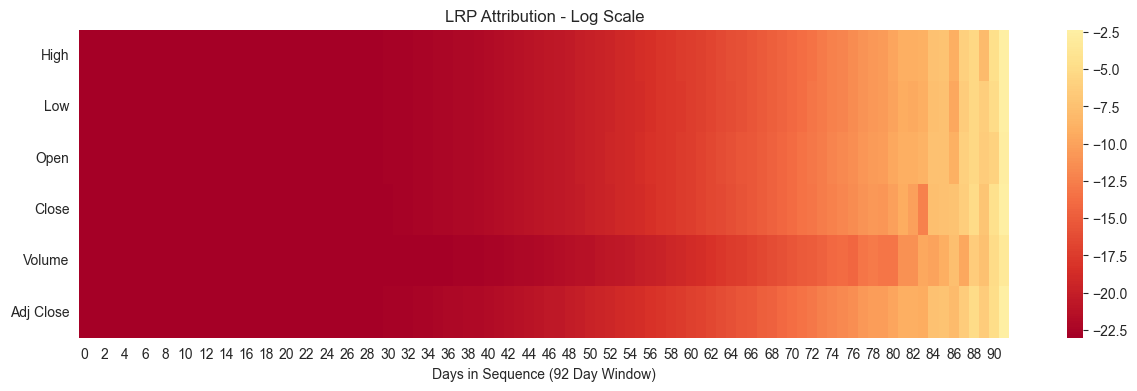

In [54]:
# plotting results
def plot_xai(data, title):
    """Creates a heatmap using logscale"""
    plt.figure(figsize=(15, 4))
    sns.heatmap(np.log(np.abs(data.T) + 1e-10), cmap="RdYlGn", center=0, yticklabels=test_df.columns)
    plt.title(title + " - Log Scale")
    plt.xlabel("Days in Sequence (92 Day Window)")
    plt.show()

plot_xai(avg_ig, "Integrated Gradients (Mean Baseline)")
plot_xai(avg_lrp, "LRP Attribution")

In [63]:
def get_critical_windows(attribution_data, k):
    """
    Identifies the top-k most important days by summing
     the absolute relevance scores across all features for each of the 92 days.
    """
    # sum across the feature dimension (axis 1 of the 92x6 array)
    temporal_importance = np.sum(np.abs(attribution_data), axis=1)

    # find the indices of the top-k days
    top_k_indices = np.argsort(temporal_importance)[-k:][::-1]

    return temporal_importance, top_k_indices

# IG
importance_scores_ig, critical_days_ig = get_critical_windows(avg_ig, k=10)
importance_scores_lrp, critical_days_lrp = get_critical_windows(avg_lrp, k=10)

print(f"Top 10 Critical Days (0-91) - IG method: {critical_days_ig}")
for i, day in enumerate(critical_days_ig):
    print(f"Rank {i+1}: Day {day} with Total Relevance: {importance_scores_ig[day]:.6f}")
print("\n")
print(f"Top 10 Critical Days (0-91) - LRP method: {critical_days_lrp}")
for i, day in enumerate(critical_days_lrp):
    print(f"Rank {i+1}: Day {day} with Total Relevance: {importance_scores_lrp[day]:.6f}")

Top 10 Critical Days (0-91) - IG method: [91 88 90 87 89 85 84 86 83 81]
Rank 1: Day 91 with Total Relevance: 0.060024
Rank 2: Day 88 with Total Relevance: 0.003833
Rank 3: Day 90 with Total Relevance: 0.003646
Rank 4: Day 87 with Total Relevance: 0.001569
Rank 5: Day 89 with Total Relevance: 0.000985
Rank 6: Day 85 with Total Relevance: 0.000430
Rank 7: Day 84 with Total Relevance: 0.000383
Rank 8: Day 86 with Total Relevance: 0.000177
Rank 9: Day 83 with Total Relevance: 0.000104
Rank 10: Day 81 with Total Relevance: 0.000082


Top 10 Critical Days (0-91) - LRP method: [91 90 88 87 89 85 84 86 83 81]
Rank 1: Day 91 with Total Relevance: 0.465375
Rank 2: Day 90 with Total Relevance: 0.048272
Rank 3: Day 88 with Total Relevance: 0.028540
Rank 4: Day 87 with Total Relevance: 0.010033
Rank 5: Day 89 with Total Relevance: 0.006972
Rank 6: Day 85 with Total Relevance: 0.003142
Rank 7: Day 84 with Total Relevance: 0.002578
Rank 8: Day 86 with Total Relevance: 0.001825
Rank 9: Day 83 with To